In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.visualization
import pandas
import named_arrays as na
import esis

In [2]:
instrument = esis.flights.f2.optics.design_single(num_distribution=0)
grating = instrument.grating

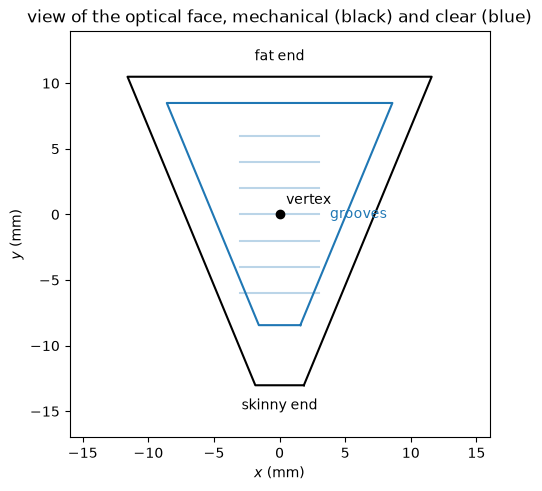

In [3]:
surface = grating.surface

y_skinny = -(grating.halfwidth_inner + grating.width_border_inner)
y_fat = grating.halfwidth_outer + grating.width_border

with astropy.visualization.quantity_support():
    fig, ax = plt.subplots(constrained_layout=True)
    ax.set_aspect("equal")
    surface.aperture_mechanical.plot(
        ax=ax,
        components=("y", "x"),
        color="black",
    )
    surface.aperture.plot(
        ax=ax,
        components=("y", "x"),
        color="tab:blue",
    )
    ax.scatter(0 * u.mm, 0 * u.mm, color="black", zorder=3)
    ax.text(x=0.5, y=0.8, s="vertex")
    for y_groove in np.linspace(-6, 6, 7):
        ax.plot(
            [-3, 3] * u.mm,
            [y_groove, y_groove] * u.mm,
            color="tab:blue",
            alpha=0.3,
        )
    ax.text(
        x=0,
        y=y_skinny.to_value(u.mm) - 1,
        s="skinny end",
        ha="center",
        va="top",
    )
    ax.text(
        x=0,
        y=y_fat.to_value(u.mm) + 1,
        s="fat end",
        ha="center",
        va="bottom",
    )
    ax.text(
        x=6,
        y=0,
        s="grooves",
        ha="center",
        va="center",
        color="tab:blue",
    )
    ax.set_xlim(-16, 16)
    ax.set_ylim(-17, 14)
    ax.set_xlabel(f"$x$ ({ax.get_xlabel()})")
    ax.set_ylabel(f"$y$ ({ax.get_ylabel()})")
    ax.set_title("view of the optical face, mechanical (black) and clear (blue)")

In [4]:
grating.rulings.spacing

Polynomial1dRulingSpacing(
    coefficients={0: <Quantity 0.0005579 mm>, 1: <Quantity -1.79596543e-05 um / mm>, 2: <Quantity -1.6761426e-07 um / mm2>},
    normal=Cartesian3dVectorArray(x=1, y=0, z=0),
    transformation=None,
)

In [5]:
y = na.linspace(y_skinny, y_fat, axis="y", num=25)

position = na.Cartesian3dVectorArray(x=y, y=0 * u.mm, z=0 * u.mm)
normal = na.Cartesian3dVectorArray(0, 0, -1)

spacing = grating.rulings.spacing(position, normal).length

print(
    pandas.DataFrame(
        {
            "y (mm)": y.ndarray.to_value(u.mm),
            "spacing (um)": spacing.ndarray.to_value(u.um),
            "density (1/mm)": (1 / spacing).ndarray.to_value(1 / u.mm),
        }
    )
)

       y (mm)  spacing (um)  density (1/mm)
0  -13.020000      0.558108     1791.767116
1  -12.040417      0.558095     1791.810388
2  -11.060833      0.558081     1791.854695
3  -10.081250      0.558067     1791.900037
4   -9.101667      0.558052     1791.946414
5   -8.122083      0.558038     1791.993827
6   -7.142500      0.558023     1792.042275
7   -6.162917      0.558007     1792.091759
8   -5.183333      0.557991     1792.142279
9   -4.203750      0.557975     1792.193835
10  -3.224167      0.557959     1792.246427
11  -2.244583      0.557942     1792.300056
12  -1.265000      0.557925     1792.354721
13  -0.285417      0.557908     1792.410423
14   0.694167      0.557890     1792.467162
15   1.673750      0.557872     1792.524938
16   2.653333      0.557854     1792.583751
17   3.632917      0.557835     1792.643603
18   4.612500      0.557816     1792.704492
19   5.592083      0.557797     1792.766419
20   6.571667      0.557778     1792.829384
21   7.551250      0.557758     

In [6]:
wavelength_center = (
    esis.flights.f2.wavelength_Ne_VII + esis.flights.f2.wavelength_Si_XII
) / 2

ratio = esis.flights.f2.wavelength_HeNe / wavelength_center
ratio = ratio.to(u.dimensionless_unscaled)
ratio

<Quantity 13.1200972>

In [7]:
instrument_visible = esis.flights.f2.optics.design_visible(num_distribution=0)
grating_visible = instrument_visible.grating

grating_visible.rulings.spacing

Polynomial1dRulingSpacing(
    coefficients={0: <Quantity 0.00731974 mm>, 1: <Quantity -0.00023563 um / mm>, 2: <Quantity -2.19911538e-06 um / mm2>},
    normal=Cartesian3dVectorArray(x=1, y=0, z=0),
    transformation=None,
)

In [8]:
spacing_visible = grating_visible.rulings.spacing(position, normal).length

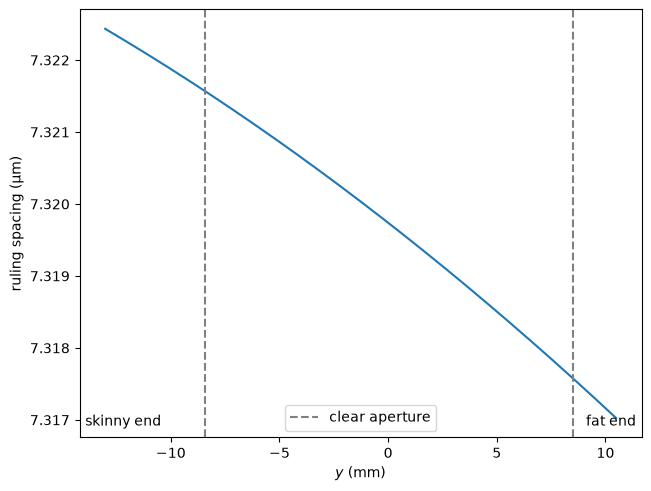

In [9]:
with astropy.visualization.quantity_support():
    fig, ax = plt.subplots(constrained_layout=True)
    na.plt.plot(y, spacing_visible.to(u.um), ax=ax, color="tab:blue")
    ax.axvline(
        -grating.halfwidth_inner.to_value(u.mm),
        color="gray",
        linestyle="--",
    )
    ax.axvline(
        grating.halfwidth_outer.to_value(u.mm),
        color="gray",
        linestyle="--",
        label="clear aperture",
    )
    ax.text(0.01, 0.02, "skinny end", transform=ax.transAxes, ha="left", va="bottom")
    ax.text(0.99, 0.02, "fat end", transform=ax.transAxes, ha="right", va="bottom")
    ax.set_xlabel(f"$y$ ({ax.get_xlabel()})")
    ax.set_ylabel(f"ruling spacing ({ax.get_ylabel()})")
    ax.legend()

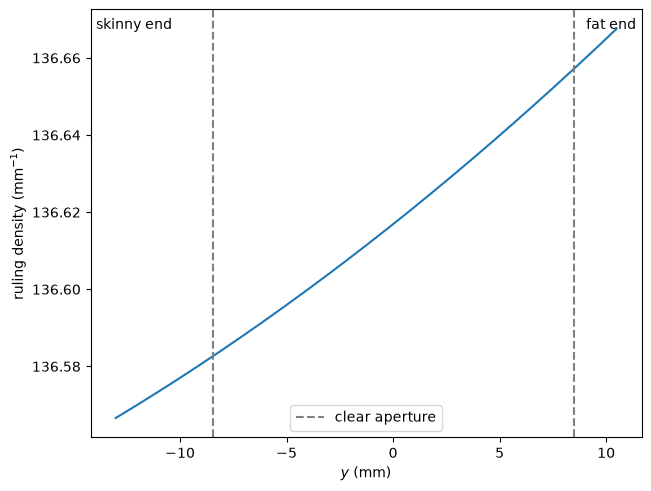

In [10]:
with astropy.visualization.quantity_support():
    fig, ax = plt.subplots(constrained_layout=True)
    na.plt.plot(y, (1 / spacing_visible).to(1 / u.mm), ax=ax, color="tab:blue")
    ax.axvline(
        -grating.halfwidth_inner.to_value(u.mm),
        color="gray",
        linestyle="--",
    )
    ax.axvline(
        grating.halfwidth_outer.to_value(u.mm),
        color="gray",
        linestyle="--",
        label="clear aperture",
    )
    ax.text(0.01, 0.98, "skinny end", transform=ax.transAxes, ha="left", va="top")
    ax.text(0.99, 0.98, "fat end", transform=ax.transAxes, ha="right", va="top")
    ax.set_xlabel(f"$y$ ({ax.get_xlabel()})")
    ax.set_ylabel(f"ruling density ({ax.get_ylabel()})")
    ax.legend()

In [11]:
print(
    pandas.DataFrame(
        {
            "y (mm)": y.ndarray.to_value(u.mm),
            "spacing (um)": spacing_visible.ndarray.to_value(u.um),
            "density (1/mm)": (1 / spacing_visible).ndarray.to_value(1 / u.mm),
        }
    )
)

       y (mm)  spacing (um)  density (1/mm)
0  -13.020000      7.322434      136.566604
1  -12.040417      7.322258      136.569902
2  -11.060833      7.322077      136.573279
3  -10.081250      7.321891      136.576735
4   -9.101667      7.321702      136.580270
5   -8.122083      7.321508      136.583883
6   -7.142500      7.321310      136.587576
7   -6.162917      7.321108      136.591348
8   -5.183333      7.320902      136.595198
9   -4.203750      7.320691      136.599128
10  -3.224167      7.320476      136.603136
11  -2.244583      7.320257      136.607224
12  -1.265000      7.320034      136.611390
13  -0.285417      7.319806      136.615636
14   0.694167      7.319575      136.619961
15   1.673750      7.319339      136.624364
16   2.653333      7.319099      136.628847
17   3.632917      7.318854      136.633409
18   4.612500      7.318606      136.638050
19   5.592083      7.318353      136.642770
20   6.571667      7.318096      136.647569
21   7.551250      7.317835     

2026-08-29 20:20:48 - astropy - WARNING: function 'sqrt' is not known to astropy's Quantity. Will run it anyway, hoping it will treat ndarray subclasses correctly. Please raise an issue at https://github.com/astropy/astropy/issues.


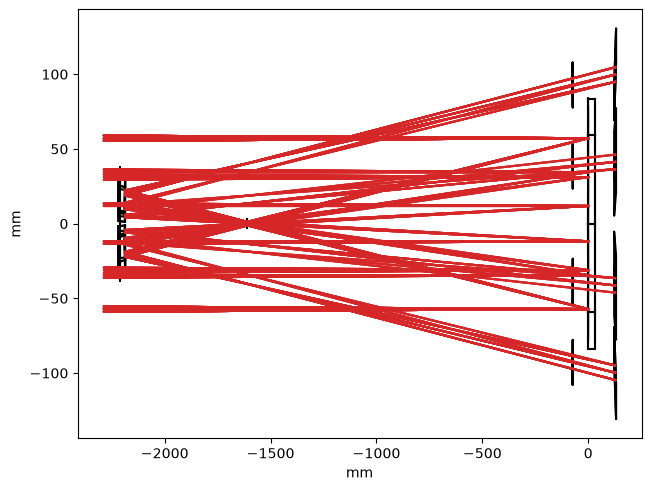

In [12]:
instrument_visible.field.num = 3
instrument_visible.pupil.num = 3

with astropy.visualization.quantity_support():
    fig, ax = plt.subplots(constrained_layout=True)
    instrument_visible.system.plot(
        components=("z", "x"),
        color="black",
        kwargs_rays=dict(
            color="tab:red",
        ),
    );

In [13]:
rays_visible = instrument_visible.system.rayfunction().outputs

where = rays_visible.unvignetted
position_visible = (rays_visible.position.x * where).sum() / where.sum()
position_visible.ndarray.to(u.mm)

<Quantity -1.00562937 mm>

In [14]:
instrument_euv = esis.flights.f2.optics.design(num_distribution=0)
instrument_euv.field.num = 3
instrument_euv.pupil.num = 3

rays_euv = instrument_euv.system.rayfunction().outputs

axis = tuple(a for a in rays_euv.position.x.shape if a != "wavelength")

where = rays_euv.unvignetted
position_euv = (rays_euv.position.x * where).sum(axis=axis) / where.sum(axis=axis)
position_euv.ndarray.to(u.mm)

<Quantity [-8.34715998,  6.34929084] mm>

In [15]:
position_difference = position_visible - position_euv.mean(axis="wavelength")
position_difference.ndarray.to(u.um)

<Quantity -6.69479873 um>